# Mutual Funds Analytics – Performance Analytics

## Project Overview

This notebook performs advanced performance analytics on 40 mutual fund schemes using historical NAV data and benchmark indices. The analysis evaluates return generation, risk-adjusted performance, downside risk, benchmark sensitivity, maximum drawdown, and develops a composite scorecard for ranking mutual funds.

The notebook generates analytical tables, performance metrics, benchmark comparisons and exports the final outputs for reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
industry_folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
investor = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print(nav_history.columns.tolist())


['amfi_code', 'date', 'nav']


In [4]:
# DATA PREPARATION

nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)
print(nav_history.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [5]:
#DAILY RETURN ANALYSIS
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)
daily_return_summary = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(
        Mean_Return="mean",
        Std_Deviation="std",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)
daily_return_summary.head()

,amfi_code,Mean_Return,Std_Deviation,Minimum,Maximum
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


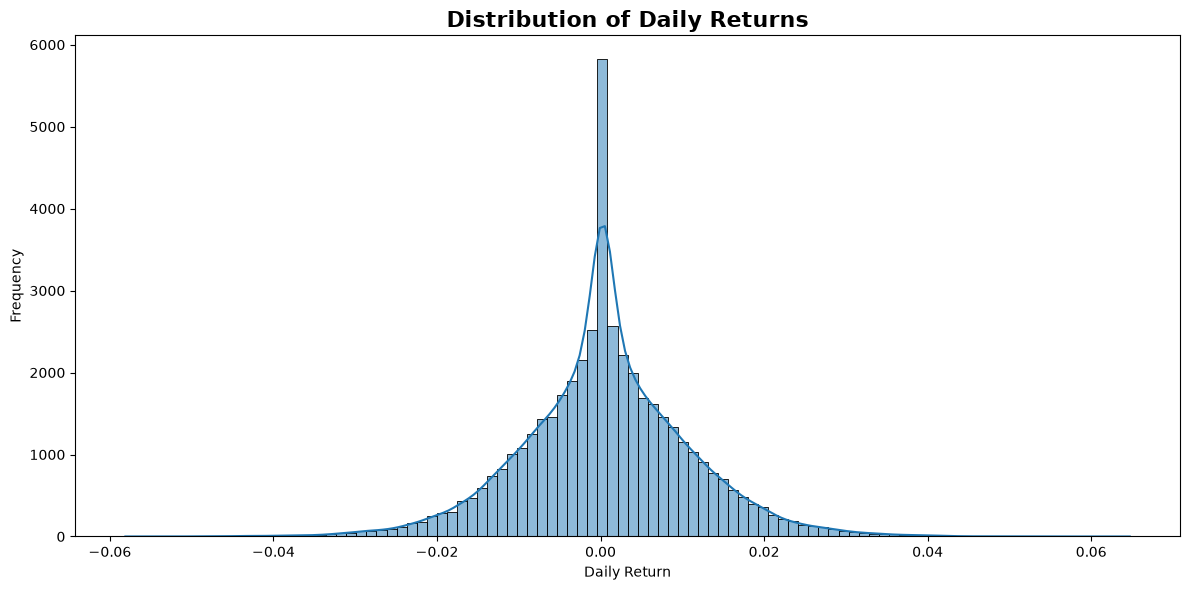

In [6]:
#DISTRIBUTION PLOT 
plt.figure(figsize=(12,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Daily Returns",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
daily_return_summary.to_csv(
    "../reports/daily_return_summary.csv",
    index=False
)

print("Daily Return Summary exported successfully.")

Daily Return Summary exported successfully.


## Insight 1

The distribution of daily returns is approximately centered around zero, indicating stable day-to-day NAV movements. Most observations fall within a narrow return range, while only a few extreme positive or negative returns are observed, suggesting relatively low daily volatility across the mutual fund schemes.

# CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized return generated by a mutual fund over a specified investment horizon. It smooths out fluctuations and provides a standardized measure of long-term performance.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1/n) - 1

In [8]:
# CAGR CALCULATION

# Merge scheme names

cagr_df = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

latest_date = cagr_df["date"].max()

periods = {
    "1Y": 365,
    "3Y": 365*3,
    "5Y": 365*5
}

results = []

for amfi, group in cagr_df.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_nav = group.iloc[-1]["nav"]

    scheme = group.iloc[-1]["scheme_name"]

    row = {
        "amfi_code": amfi,
        "scheme_name": scheme
    }

    for label, days in periods.items():

        target_date = latest_date - pd.Timedelta(days=days)

        historical = group[group["date"] <= target_date]

        if len(historical) == 0:

            row[f"CAGR_{label}"] = np.nan

            continue

        start_nav = historical.iloc[-1]["nav"]

        years = days / 365

        cagr = ((latest_nav / start_nav) ** (1 / years)) - 1

        row[f"CAGR_{label}"] = cagr * 100

    results.append(row)

cagr_table = pd.DataFrame(results)

cagr_table.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.030698,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.902496,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.446898,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.669133,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.693652,NaN


In [9]:
cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.334366,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.162703,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,33.144774,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.446898,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.517893,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.348209,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.691888,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.669133,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,28.392402,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,65.138719,26.931965,NaN


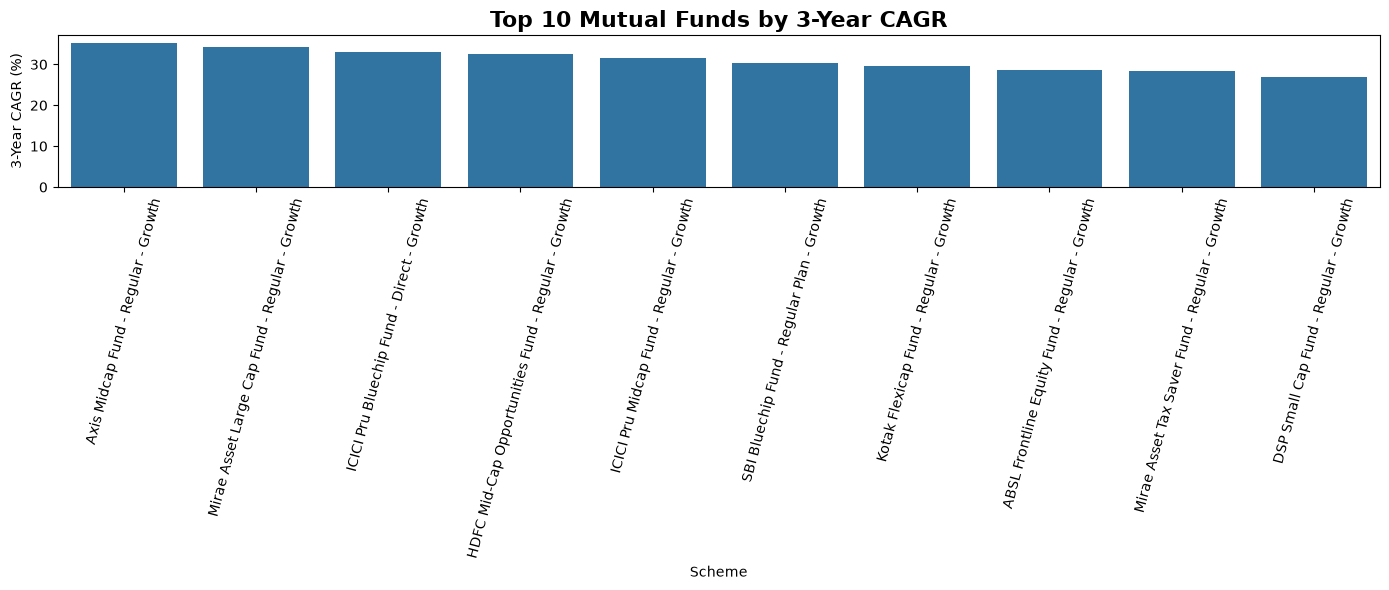

In [10]:
top10 = (
    cagr_table
    .sort_values("CAGR_3Y", ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top10,
    x="scheme_name",
    y="CAGR_3Y"
)

plt.xticks(rotation=75)

plt.xlabel("Scheme")

plt.ylabel("3-Year CAGR (%)")

plt.title(
    "Top 10 Mutual Funds by 3-Year CAGR",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [11]:
plt.tight_layout()

plt.savefig(
    "../reports/cagr_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [12]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison exported successfully.")

CAGR comparison exported successfully.


## Insight 2

The CAGR comparison highlights significant differences in long-term wealth creation among the mutual fund schemes. Funds with consistently higher 3-year CAGR demonstrate stronger sustained performance, while lower CAGR values indicate relatively slower capital appreciation over the investment horizon.

# Sharpe Ratio Analysis

The Sharpe Ratio measures the risk-adjusted return generated by a mutual fund.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

where:

- Rp = Average Daily Return
- Rf = Risk-free Rate (6.5% annual)
- σ = Standard Deviation of Daily Returns
- 252 = Average trading days in a year

In [13]:
# SHARPE RATIO
RISK_FREE_RATE = 0.065          # Annual
daily_rf = RISK_FREE_RATE / 252
sharpe_results = []
for amfi, group in nav_history.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 2:
        continue
    avg_return = returns.mean()
    std_return = returns.std()
    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)
    sharpe_results.append({
        "amfi_code": amfi,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Merge scheme names
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

# Ranking
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name,Sharpe_Rank
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,6.0
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,8.0
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9.0
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10.0


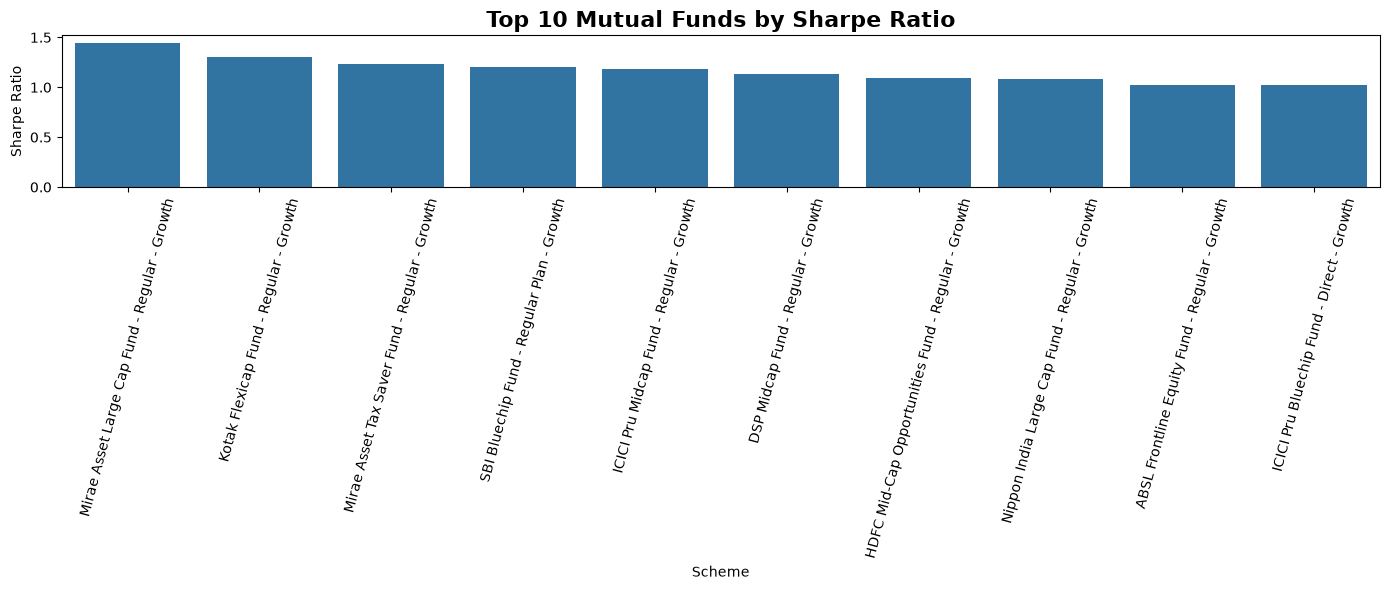

Sharpe Ratio chart exported successfully!


In [14]:
top10 = sharpe_df.head(10)

fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(

    data=top10,

    x="scheme_name",

    y="Sharpe_Ratio",

    ax=ax

)

ax.set_title(

    "Top 10 Mutual Funds by Sharpe Ratio",

    fontsize=16,

    fontweight="bold"

)

ax.set_xlabel("Scheme")

ax.set_ylabel("Sharpe Ratio")

plt.xticks(rotation=75)

plt.tight_layout()

fig.savefig(

    "../reports/sharpe_ratio_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("Sharpe Ratio chart exported successfully!")

In [15]:
sharpe_df.to_csv(

    "../reports/sharpe_ratio.csv",

    index=False

)

print("Sharpe Ratio table exported successfully!")

Sharpe Ratio table exported successfully!


## Insight 3

Funds with higher Sharpe Ratios delivered better returns for each unit of total risk undertaken. These schemes demonstrate superior risk-adjusted performance and are generally more efficient investments over the study period.

# Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted performance by considering only downside volatility.

Unlike the Sharpe Ratio, the Sortino Ratio penalizes only negative returns, making it a more appropriate metric for evaluating investment performance.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Standard Deviation × √252

In [16]:
# SORTINO RATIO

RISK_FREE_RATE = 0.065
daily_rf = RISK_FREE_RATE / 252

sortino_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    avg_return = returns.mean()

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({

        "amfi_code": amfi,

        "Sortino_Ratio": sortino

    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.merge(

    fund_master[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"

)

sortino_df["Sortino_Rank"] = (

    sortino_df["Sortino_Ratio"]

    .rank(

        ascending=False,

        method="dense"

    )

)

sortino_df = sortino_df.sort_values(

    "Sortino_Ratio",

    ascending=False

)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name,Sortino_Rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6.0
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7.0
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8.0
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9.0
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10.0


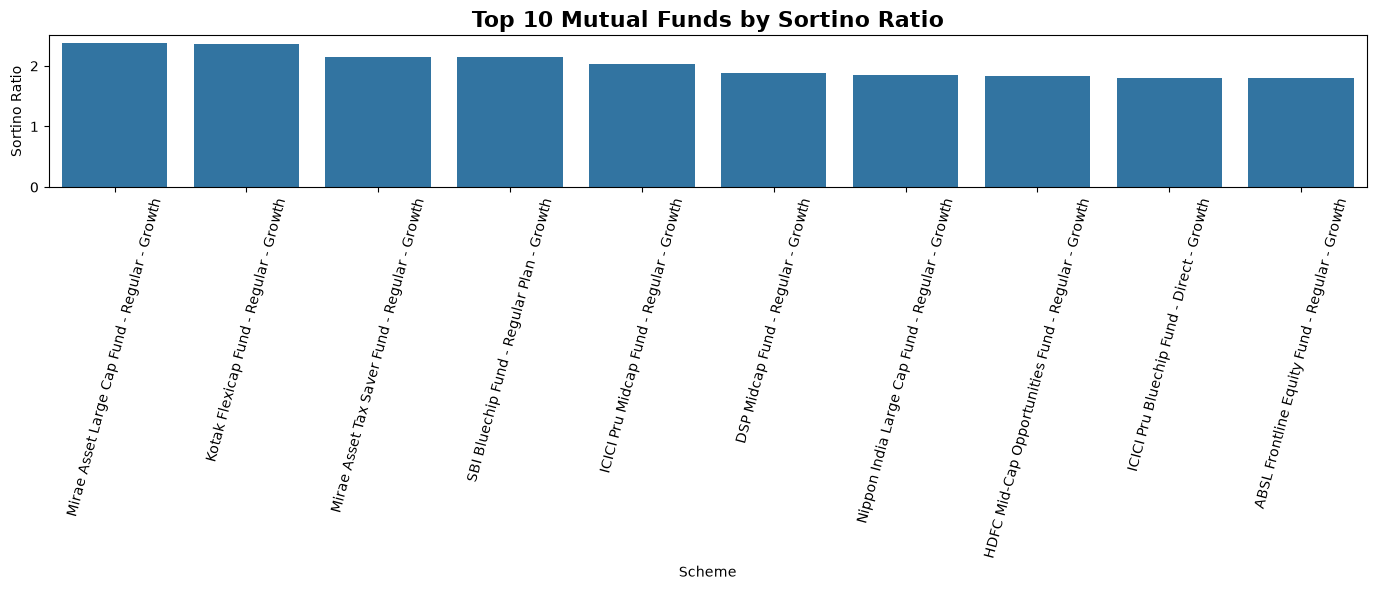

In [17]:
top10 = sortino_df.head(10)

fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(

    data=top10,

    x="scheme_name",

    y="Sortino_Ratio",

    ax=ax

)

ax.set_title(

    "Top 10 Mutual Funds by Sortino Ratio",

    fontsize=16,

    fontweight="bold"

)

ax.set_xlabel("Scheme")

ax.set_ylabel("Sortino Ratio")

plt.xticks(rotation=75)

plt.tight_layout()

fig.savefig(

    "../reports/sortino_ratio_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [18]:
sortino_df.to_csv(

    "../reports/sortino_ratio.csv",

    index=False

)

print("Sortino Ratio exported successfully.")

Sortino Ratio exported successfully.


## Insight 4

The Sortino Ratio highlights funds that generated strong returns while minimizing downside risk. Funds with higher Sortino Ratios demonstrated superior protection during negative market movements, making them attractive from a downside risk perspective.

# Alpha and Beta Analysis

Alpha and Beta are calculated using Ordinary Least Squares (OLS) regression between fund daily returns and benchmark daily returns.

- Beta measures the sensitivity of a fund to market movements.
- Alpha measures the excess return generated by the fund after accounting for market risk.

Formula:

Fund Return = Alpha + Beta × Benchmark Return

In [30]:
# ALPHA & BETA

# Use Nifty 100 as benchmark
benchmark_nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_nifty100 = benchmark_nifty100.sort_values("date")

benchmark_nifty100["benchmark_return"] = (
    benchmark_nifty100["close_value"].pct_change()
)

print("Benchmark rows:", len(benchmark_nifty100))
benchmark_nifty100.head()

alpha_beta_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        benchmark_nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": amfi,
        "Alpha": regression.intercept * 252,
        "Beta": regression.slope,
        "R_Squared": regression.rvalue ** 2,
        "P_Value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df = alpha_beta_df.merge(
    scheme_performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta_df.head(10)

Benchmark rows: 1150


,amfi_code,Alpha,Beta,R_Squared,P_Value,scheme_name
21,119598,0.303370,-0.023196,1.414258e-04,0.687179,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,3.532991e-05,0.840494,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,1.345534e-07,0.990090,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,1.748889e-04,0.654295,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,3.430543e-04,0.530528,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,1.206652e-05,0.906369,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,4.625437e-04,0.466427,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,3.357978e-06,0.950525,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,1.936879e-03,0.135988,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,8.869789e-04,0.313143,SBI Bluechip Fund - Regular Plan - Growth


# Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest peak-to-trough decline in a fund's NAV over the observation period.

Formula:

Maximum Drawdown = (Current NAV / Running Maximum NAV) − 1

A lower (less negative) drawdown indicates better downside protection during market corrections.

In [31]:
# MAXIMUM DRAWDOWN

drawdown_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    worst_row = group.loc[group["drawdown"].idxmin()]

    drawdown_results.append({
        "amfi_code": amfi,
        "Maximum_Drawdown": worst_row["drawdown"] * 100,
        "Worst_Date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.merge(
    scheme_performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_df = drawdown_df.sort_values(
    "Maximum_Drawdown"
)

drawdown_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,scheme_name
22,119599,-52.574221,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.677754,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.446916,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.171900,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.706006,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-28.001124,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-24.734441,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-24.003511,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-23.344886,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-21.751396,2023-05-22,Axis Bluechip Fund - Direct - Growth


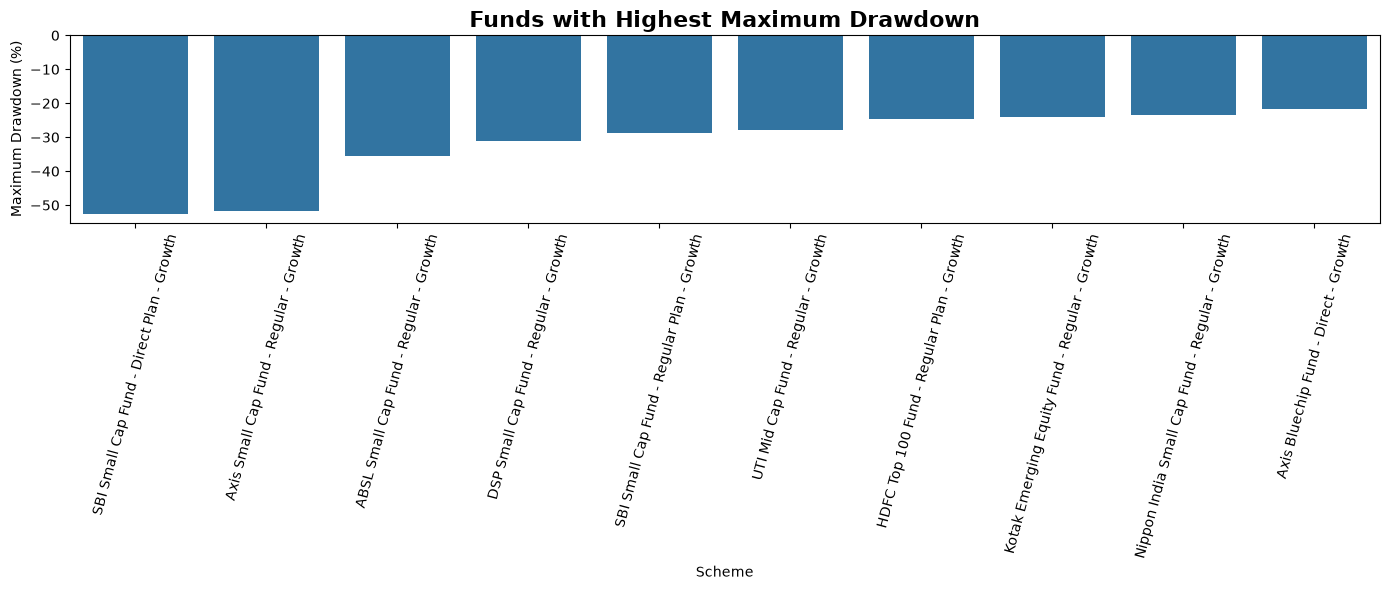

In [32]:
top10 = drawdown_df.head(10)

fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(
    data=top10,
    x="scheme_name",
    y="Maximum_Drawdown",
    ax=ax
)

ax.set_title(
    "Funds with Highest Maximum Drawdown",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Scheme")

ax.set_ylabel("Maximum Drawdown (%)")

plt.xticks(rotation=75)

plt.tight_layout()

fig.savefig(
    "../reports/maximum_drawdown_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown exported successfully.")

Maximum Drawdown exported successfully.


## Insight 6

Maximum Drawdown identifies the largest historical decline experienced by each fund. Funds with smaller drawdowns demonstrate greater resilience during market downturns and better capital preservation.

# Fund Scorecard (0–100)

The Fund Scorecard combines multiple performance metrics into a single composite score.

Weightage:

- 30% → 3-Year Return Rank
- 25% → Sharpe Ratio Rank
- 20% → Alpha Rank
- 15% → Expense Ratio Rank (Inverse)
- 10% → Maximum Drawdown Rank (Inverse)

A higher score indicates stronger overall fund performance after considering both return and risk.

In [39]:
# FUND SCORECARD

scorecard = scheme_performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-15.012385
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-11.803494
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.706006
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-52.574221
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-4.328729


In [40]:
# GENERATE RANKS

scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False,
    method="dense"
)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=False,
    method="dense"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-15.012385,26.0,4.0,10.0,24.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-11.803494,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.706006,1.0,14.0,1.0,18.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-52.574221,2.0,32.0,36.0,5.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-4.328729,38.0,37.0,34.0,8.0,5.0


In [41]:
# NORMALIZE RANKS

scorecard["Return_Score"] = (
    scorecard["Return_Rank"].max() - scorecard["Return_Rank"] + 1
) / scorecard["Return_Rank"].max()

scorecard["Sharpe_Score"] = (
    scorecard["Sharpe_Rank"].max() - scorecard["Sharpe_Rank"] + 1
) / scorecard["Sharpe_Rank"].max()

scorecard["Alpha_Score"] = (
    scorecard["Alpha_Rank"].max() - scorecard["Alpha_Rank"] + 1
) / scorecard["Alpha_Rank"].max()

scorecard["Expense_Score"] = (
    scorecard["Expense_Rank"].max() - scorecard["Expense_Rank"] + 1
) / scorecard["Expense_Rank"].max()

scorecard["Drawdown_Score"] = (
    scorecard["Drawdown_Rank"].max() - scorecard["Drawdown_Rank"] + 1
) / scorecard["Drawdown_Rank"].max()

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-15.012385,26.0,4.0,10.0,24.0,17.0,0.375,0.925,0.775,0.258065,0.600
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-11.803494,34.0,12.0,15.0,4.0,11.0,0.175,0.725,0.650,0.903226,0.750
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.706006,1.0,14.0,1.0,18.0,36.0,1.000,0.675,1.000,0.451613,0.125
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-52.574221,2.0,32.0,36.0,5.0,40.0,0.975,0.225,0.125,0.870968,0.025
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-4.328729,38.0,37.0,34.0,8.0,5.0,0.075,0.100,0.175,0.774194,0.900


In [42]:
# FINAL FUND SCORE

scorecard["Fund_Score"] = (

    scorecard["Return_Score"] * 30 +

    scorecard["Sharpe_Score"] * 25 +

    scorecard["Alpha_Score"] * 20 +

    scorecard["Expense_Score"] * 15 +

    scorecard["Drawdown_Score"] * 10

)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard["Overall_Rank"] = range(
    1,
    len(scorecard) + 1
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score,Overall_Rank
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-18.188514,8.0,5.0,3.0,14.0,25.0,0.825,0.900,0.950,0.580645,0.400,78.959677,1
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-12.973968,11.0,2.0,5.0,19.0,13.0,0.750,0.975,0.900,0.419355,0.700,78.165323,2
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-16.217209,10.0,7.0,6.0,15.0,20.0,0.775,0.850,0.875,0.548387,0.525,75.475806,3
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.706006,1.0,14.0,1.0,18.0,36.0,1.000,0.675,1.000,0.451613,0.125,74.899194,4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-11.265729,17.0,1.0,7.0,20.0,8.0,0.600,1.000,0.850,0.387097,0.825,74.056452,5
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-31.171900,6.0,13.0,2.0,22.0,37.0,0.875,0.700,0.975,0.322581,0.100,69.088710,6
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-17.248106,9.0,6.0,8.0,30.0,22.0,0.800,0.875,0.825,0.064516,0.475,68.092742,7
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-12.588276,20.0,10.0,13.0,11.0,12.0,0.525,0.775,0.700,0.677419,0.725,66.536290,8
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-20.960884,15.0,11.0,9.0,15.0,28.0,0.650,0.750,0.800,0.548387,0.325,65.725806,9
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-16.396743,23.0,3.0,4.0,29.0,21.0,0.450,0.950,0.925,0.096774,0.500,62.201613,10


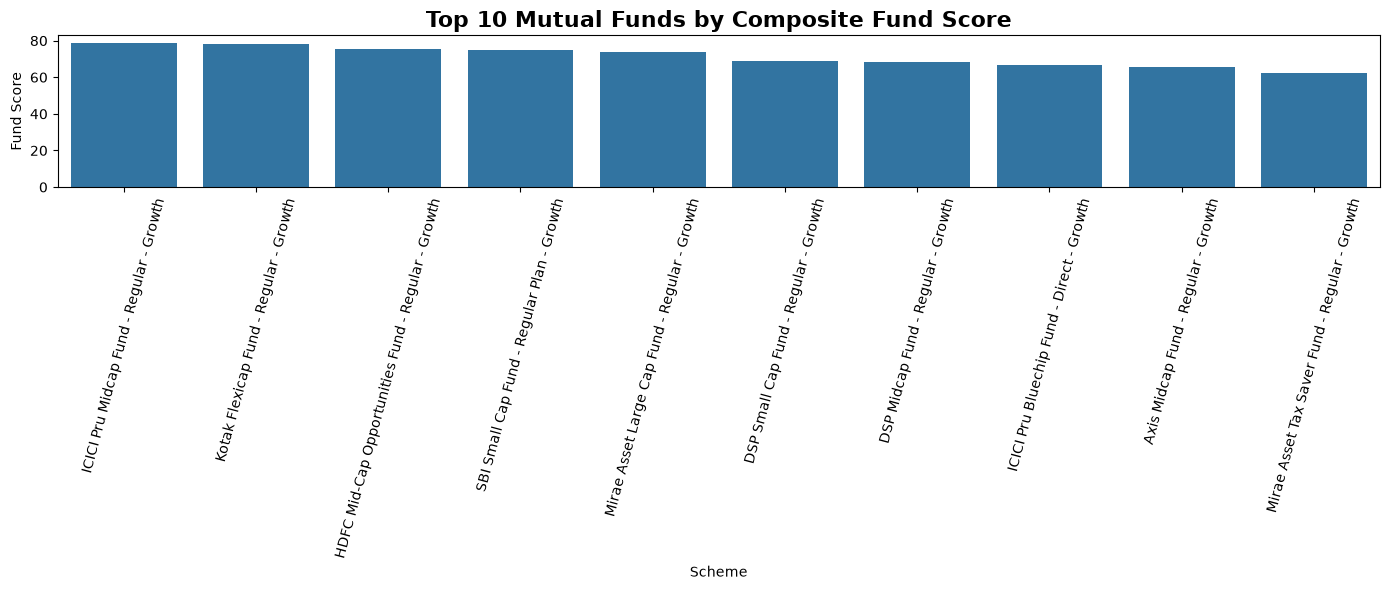

In [43]:
top10 = scorecard.head(10)

fig, ax = plt.subplots(figsize=(14,6))

sns.barplot(
    data=top10,
    x="scheme_name",
    y="Fund_Score",
    ax=ax
)

ax.set_title(
    "Top 10 Mutual Funds by Composite Fund Score",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Scheme")

ax.set_ylabel("Fund Score")

plt.xticks(rotation=75)

plt.tight_layout()

fig.savefig(
    "../reports/fund_scorecard_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard exported successfully.")

Fund Scorecard exported successfully.


## Insight 7

The composite Fund Score combines long-term return, risk-adjusted performance, benchmark outperformance, expense efficiency, and downside protection into a unified metric. Funds with higher scores consistently demonstrate stronger overall investment quality across multiple evaluation criteria.

# Benchmark Comparison

This section compares the performance of the five highest-ranked mutual funds against the NIFTY50 and NIFTY100 benchmark indices over the last three years.

Tracking Error is also computed to measure how closely each fund follows the benchmark.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [45]:
# PREPARE BENCHMARK COMPARISON

# Top 5 funds
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_names = scorecard.head(5)[["amfi_code", "scheme_name"]]

# Last 3 years
latest_date = nav_history["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = nav_history[
    (nav_history["amfi_code"].isin(top5_codes)) &
    (nav_history["date"] >= start_date)
].copy()

top5_nav = top5_nav.merge(
    top5_names,
    on="amfi_code",
    how="left"
)

benchmark_compare = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare = benchmark_compare[
    benchmark_compare["date"] >= start_date
]

In [46]:
# NORMALIZE PERFORMANCE

top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_compare["Normalized_Index"] = (
    benchmark_compare.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

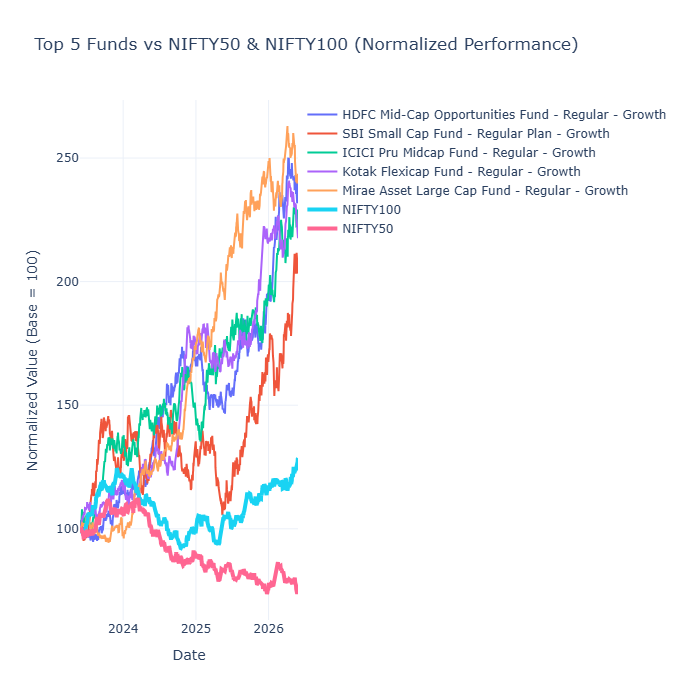

In [47]:
# BENCHMARK COMPARISON CHART

fig = go.Figure()

# Top 5 Funds
for scheme in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized_NAV"],
            mode="lines",
            name=scheme
        )
    )

# Benchmarks
for index in benchmark_compare["index_name"].unique():

    temp = benchmark_compare[
        benchmark_compare["index_name"] == index
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized_Index"],
            mode="lines",
            line=dict(width=4),
            name=index
        )
    )

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    template="plotly_white",
    height=700
)

fig.show()

fig.write_image(
    "../reports/benchmark_comparison.png",
    width=1800,
    height=900,
    scale=3
)

In [48]:
# TRACKING ERROR

benchmark_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "close_value"]].copy()

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

tracking_results = []

for amfi in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        benchmark_returns[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": amfi,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_results)

tracking_error_df = tracking_error_df.merge(
    top5_names,
    on="amfi_code",
    how="left"
)

tracking_error_df

,amfi_code,Tracking_Error,scheme_name
0,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth


In [49]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error exported successfully.")

Tracking Error exported successfully.


## Insight 8

The benchmark comparison demonstrates how the highest-ranked mutual funds performed relative to the NIFTY50 and NIFTY100 indices over the last three years. Tracking Error quantifies the deviation of fund returns from the benchmark, where lower values indicate closer benchmark replication and higher values reflect greater active management.